## Clean version of our assignment

Importing packages 

In [1]:
import pandas as pd
import os
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn import datasets as ds
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import decomposition

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import neighbors

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import sklearn.metrics as sklm
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report, average_precision_score, precision_recall_curve, PrecisionRecallDisplay
from scipy.stats import ttest_ind
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

Load data 

In [2]:
with zipfile.ZipFile("ecg_data.zip","r") as zip_ref:
    zip_ref.extractall("ecg_data")

def load_data():
    this_directory = os.getcwd()
    data = pd.read_csv(os.path.join(this_directory, 'ecg_data/ecg_data.csv'), index_col=0)
    return data

raw_data = load_data()

Data description

In [3]:
print(f'The number of samples: {len(raw_data.index)}')
print(f'The number of columns: {len(raw_data.columns)}')

print(f'The number of NaN values in the entire dataframe: {raw_data.isnull().sum().sum()}')
print(f'The number of samples with label 0: {len(raw_data[raw_data["label"] == 0])}')
print(f'The number of samples with label 1: {len(raw_data[raw_data["label"] == 1])}')
print(f'The percentage of samples with label 0 is thus {len(raw_data[raw_data["label"] == 0])/len(raw_data.index)*100:.2f}%', 
      f'and the percentage with label 1 {len(raw_data[raw_data["label"] == 1])/len(raw_data.index)*100:.2f}%')

# print(raw_data.groupby('label').count())
# print(raw_data.groupby('label').mean())
# print(raw_data.groupby('label').var())
# print(raw_data.groupby('label').std())


The number of samples: 827
The number of columns: 9001
The number of NaN values in the entire dataframe: 0
The number of samples with label 0: 681
The number of samples with label 1: 146
The percentage of samples with label 0 is thus 82.35% and the percentage with label 1 17.65%


Splitting the data in training and test sets

In [4]:
X = raw_data.drop('label', axis=1)
Y = raw_data['label']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=4, stratify=Y)

Preprocessing of data

In [ ]:


import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

print(f"Preprocessing begint met {np.shape(x_train)[1]} features")

redundant_features_variance = []
for col in x_train.columns:
    if np.var(x_train[col]) < 0.01:
        redundant_features_variance.append(col)

x_train_var = x_train.drop(columns=redundant_features_variance)
x_test_var = x_test.drop(columns=redundant_features_variance)
print(f"Variantie-analyse verwijderde {len(redundant_features_variance)} features")

correlation_matrix = x_train_var.corr().abs()
correlation_matrix_no_duplicates = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
redundant_features_correlation = []
for col in correlation_matrix.columns:
    if any(correlation_matrix_no_duplicates[col] > 0.95):
        redundant_features_correlation.append(col)

x_train_corr = x_train_var.drop(columns=redundant_features_correlation)
x_test_corr = x_test_var.drop(columns=redundant_features_correlation)
print(f"Correlatie analyse verwijderde {len(redundant_features_correlation)} features")

x_train_with_label = pd.concat([x_train_corr, y_train], axis=1)
redundant_features_ttest = []
for col in x_train_corr.columns:
    p_value = ttest_ind(
        x_train_with_label[x_train_with_label["label"] == 0][col], 
        x_train_with_label[x_train_with_label["label"] == 1][col]
    )[1]
    
    if p_value > (0.05 / np.shape(x_train_corr)[1]):
        redundant_features_ttest.append(col)

x_train_ttest = x_train_corr.drop(columns=redundant_features_ttest)
x_test_ttest = x_test_corr.drop(columns=redundant_features_ttest)
print(f"T-test analyse verwijderde {len(redundant_features_ttest)} features")

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

x_train_prep = pd.DataFrame(scaler.fit_transform(x_train_ttest), columns=x_train_ttest.columns, index=x_train.index)
x_test_prep = pd.DataFrame(scaler.transform(x_test_ttest), columns=x_test_ttest.columns, index=x_test.index)

y_train_prep = y_train
y_test_prep = y_test

print(f"Na het schalen zijn er {np.shape(x_train_prep)[1]} features over")

Preprocessing begint met 9000 features
Variantie-analyse verwijderde 0 features
Correlatie analyse verwijderde 4932 features
T-test analyse verwijderde 4021 features
Na het schalen zijn er 47 features over


Training XGBoost op jouw 47 handmatig geselecteerde features...

--- Model Evaluatie op Test Set ---
AUC-PR:    0.5061
Accuracy:  0.7952
Precision: 0.4194
Recall:    0.4483
F1-Score:  0.4333

--- Confusion Matrix ---
True Negatives (0 goed): 119
False Positives (0 fout): 18
False Negatives (1 fout): 16
True Positives (1 goed): 13


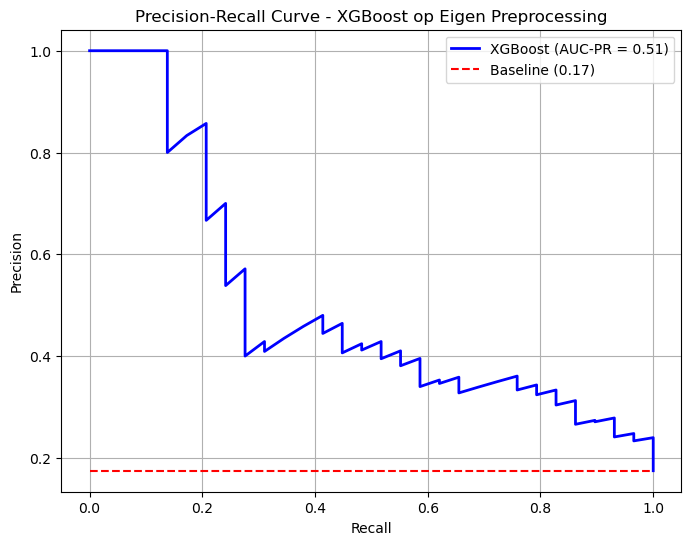

In [ ]:

scale_pos_weight_val = len(y_train_prep[y_train_prep == 0]) / len(y_train_prep[y_train_prep == 1])

print(f"Training XGBoost op jouw {x_train_prep.shape[1]} handmatig geselecteerde features...")
xgb_model_prep = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_val, 
    
    learning_rate=0.01,        
    n_estimators=300,          
    max_depth=4,                
    min_child_weight=5,         
    
    subsample=0.7,            
    colsample_bytree=0.6,      
    
    reg_alpha=0,              # L1 Regularisatie iets omhoog 
    reg_lambda=1,               # L2 Regularisatie
    
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

xgb_model_prep.fit(x_train_prep, y_train_prep)

y_pred = xgb_model_prep.predict(x_test_prep) 
y_pred_proba = xgb_model_prep.predict_proba(x_test_prep)[:, 1] 

test_auc_pr = average_precision_score(y_test_prep, y_pred_proba)
accuracy = accuracy_score(y_test_prep, y_pred)
precision_val = precision_score(y_test_prep, y_pred)
recall_val = recall_score(y_test_prep, y_pred)
f1 = f1_score(y_test_prep, y_pred)

print(f"\n--- Model Evaluatie op Test Set ---")
print(f"AUC-PR:    {test_auc_pr:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall:    {recall_val:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test_prep, y_pred)
print("True Negatives (0 goed):", cm[0,0])
print("False Positives (0 fout):", cm[0,1])
print("False Negatives (1 fout):", cm[1,0]) 
print("True Positives (1 goed):", cm[1,1])

precision, recall, _ = precision_recall_curve(y_test_prep, y_pred_proba)
baseline = len(y_test_prep[y_test_prep == 1]) / len(y_test_prep)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'XGBoost (AUC-PR = {test_auc_pr:.2f})')
plt.plot([0, 1], [baseline, baseline], linestyle='--', color='red', label=f'Baseline ({baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost op Eigen Preprocessing')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

## Volledige Pipeline met eigen Preprocessing en Cross-Validatie (Verzoek 1, 2 en 3)

Hier combineren we jouw eigen feature selectie (variantie, correlatie, t-test) met de scaler en de XGBoost in één *scikit-learn Pipeline*.
We maken een custom Transformer aan voor de correlatie en t-test.
Hierdoor kunnen we makkelijker cross-validatie (met RandomizedSearchCV) uitvoeren, en optimaliseren we de AUC-PR (average precision) op de validatie set (kruisvalidatie) voordat we definitief testen op de test set. Echte validatie dus!

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from sklearn.base import BaseEstimator, TransformerMixin

class CorrelationTTestSelector(BaseEstimator, TransformerMixin):
    def __init__(self, corr_threshold=0.95, alpha=0.05):
        self.corr_threshold = corr_threshold
        self.alpha = alpha
        self.selected_indices_ = None
        
    def fit(self, X, y):
        X_df = pd.DataFrame(X)
        y_arr = np.array(y)
        
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_corr = [column for column in upper.columns if any(upper[column] > self.corr_threshold)]
        features_after_corr = [c for c in X_df.columns if c not in to_drop_corr]
        
        features_after_ttest = []
        n_features = len(features_after_corr)
        for col in features_after_corr:
            group0 = X_df.loc[y_arr == 0, col]
            group1 = X_df.loc[y_arr == 1, col]
            
            if len(group0) > 0 and len(group1) > 0:
                p_value = ttest_ind(group0, group1)[1]
                if p_value <= (self.alpha / n_features):
                    features_after_ttest.append(col)
                
        self.selected_indices_ = features_after_ttest
        return self
        
    def transform(self, X, y=None):
        return X[:, self.selected_indices_]


Start Pipeline Kruisvalidatie + XGBoost RandomizedSearch (40 iteraties)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV] END xgb__colsample_bytree=0.7, xgb__learning_rate=0.2, xgb__max_depth=2, xgb__n_estimators=200, xgb__reg_alpha=1, xgb__reg_lambda=5, xgb__subsample=0.9; total time= 2.2min
[CV] END xgb__colsample_bytree=0.7, xgb__learning_rate=0.2, xgb__max_depth=2, xgb__n_estimators=200, xgb__reg_alpha=1, xgb__reg_lambda=5, xgb__subsample=0.9; total time= 2.2min
[CV] END xgb__colsample_bytree=0.7, xgb__learning_rate=0.2, xgb__max_depth=2, xgb__n_estimators=200, xgb__reg_alpha=1, xgb__reg_lambda=5, xgb__subsample=0.9; total time= 2.1min
[CV] END xgb__colsample_bytree=0.5, xgb__learning_rate=0.01, xgb__max_depth=5, xgb__n_estimators=200, xgb__reg_alpha=0.1, xgb__reg_lambda=50, xgb__subsample=0.5; total time=   0.7s
[CV] END xgb__colsample_bytree=0.5, xgb__learning_rate=0.01, xgb__max_depth=5, xgb__n_estimators=200, xgb__reg_alpha=0.1, xgb__reg_lambda=50, xgb__subs

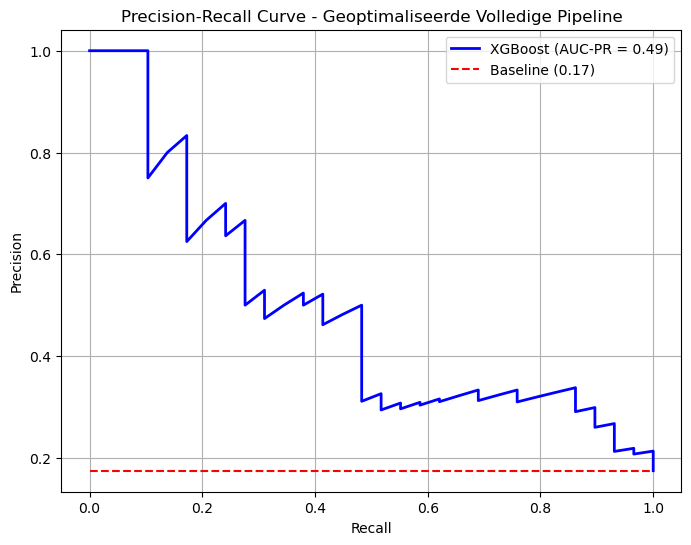

In [ ]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import average_precision_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
from tempfile import mkdtemp
from shutil import rmtree

scale_pos_weight_val = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

cachedir = mkdtemp()

pipeline = Pipeline([
    ('var_filter', VarianceThreshold(threshold=0.01)),
    ('corr_ttest_filter', CorrelationTTestSelector(corr_threshold=0.95, alpha=0.05)),
    ('scaler', RobustScaler()),
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight_val,
        random_state=42,
        eval_metric='logloss',
        tree_method='hist'
    ))
], memory=cachedir)

param_distributions = {
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2], 
    'xgb__max_depth': [2, 3, 4, 5],             
    'xgb__n_estimators': [100, 200, 300, 500],  
    'xgb__subsample': [0.5, 0.7, 0.9, 1.0],     
    'xgb__colsample_bytree': [0.5, 0.7, 0.9],   
    'xgb__reg_alpha': [0, 0.1, 1, 5],
    'xgb__reg_lambda': [1, 5, 10, 50]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=40,          
    scoring='average_precision', 
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=1
)

print("Start Pipeline Kruisvalidatie + XGBoost RandomizedSearch (40 iteraties)...")
random_search.fit(x_train, y_train)

rmtree(cachedir)

print(f"\n--- Resultaten op Validatie set (Kruisvalidatie) ---")
print(f"Beste parameters: {random_search.best_params_}")
print(f"Beste gemiddelde Validatie AUC-PR: {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(x_test)
y_pred_proba = best_model.predict_proba(x_test)[:, 1] 

test_auc_pr = average_precision_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n--- Evaluatie op Test Set ---")
print(f"Test AUC-PR: {test_auc_pr:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall:    {recall_val:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
baseline = len(y_test[y_test == 1]) / len(y_test)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'XGBoost (AUC-PR = {test_auc_pr:.2f})')
plt.plot([0, 1], [baseline, baseline], linestyle='--', color='red', label=f'Baseline ({baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Geoptimaliseerde Volledige Pipeline')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()
